Libaries/Tools

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, classification_report
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score



c:\Users\mikko\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LOAD DATASET

In [2]:
#dataset
matches = pd.read_csv('C:/Users/mikko/OneDrive/python_projektit/ML_dec_tree_football/data_csv/Matches.csv')

C:\Users\mikko\AppData\Local\Temp\ipykernel_20484\583763451.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  matches = pd.read_csv('C:/Users/mikko/OneDrive/python_projektit/ML_dec_tree_football/data_csv/Matches.csv')


DROP COLUMNS AND FILL_EMPTY

In [3]:
matches_cleaned = matches.drop(columns=['MatchTime', 'HomeFouls', 'AwayFouls',
    'HomeYellow', 'AwayYellow', 'HomeRed', 'AwayRed',
    'OddHome', 'OddDraw', 'OddAway',
    'MaxHome', 'MaxDraw', 'MaxAway',
    'Over25', 'Under25', 'MaxOver25', 'MaxUnder25',
    'HandiSize', 'HandiHome', 'HandiAway',
    'C_LTH', 'C_LTA', 'C_VHD', 'C_VAD',
    'C_HTB', 'C_PHB'
])

matches_cleaned = matches_cleaned.dropna()

FILTER AND REPLACE VALUES

In [4]:
matches_cleaned = matches_cleaned[matches_cleaned['Division'] == 'E0']
matches_cleaned['MatchDate'] = pd.to_datetime(matches_cleaned['MatchDate'])

matches_cleaned[['HomeTeam', 'AwayTeam']] = (
    matches_cleaned[['HomeTeam', 'AwayTeam']]
        .replace({
            "Nott'm Forest": "Nottingham Forest",
            "Nottm Forest": "Nottingham Forest"
        })
)

matches_cleaned['HomePoints'] = matches_cleaned['FTResult'].map({
    'H': 3,
    'D': 1,
    'A': 0
})

matches_cleaned['AwayPoints'] = matches_cleaned['FTResult'].map({
    'H': 0,
    'D': 1,
    'A': 3
})

matches_cleaned['FTResult'] = matches_cleaned['FTResult'].map({
    'H': 0,
    'D': 1,
    'A': 2
})

In [5]:
matches_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9408 entries, 154 to 230510
Data columns (total 24 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Division     9408 non-null   object        
 1   MatchDate    9408 non-null   datetime64[ns]
 2   HomeTeam     9408 non-null   object        
 3   AwayTeam     9408 non-null   object        
 4   HomeElo      9408 non-null   float64       
 5   AwayElo      9408 non-null   float64       
 6   Form3Home    9408 non-null   float64       
 7   Form5Home    9408 non-null   float64       
 8   Form3Away    9408 non-null   float64       
 9   Form5Away    9408 non-null   float64       
 10  FTHome       9408 non-null   float64       
 11  FTAway       9408 non-null   float64       
 12  FTResult     9408 non-null   int64         
 13  HTHome       9408 non-null   float64       
 14  HTAway       9408 non-null   float64       
 15  HTResult     9408 non-null   object        
 16  HomeSho

ROLLING AVERAGES FOR TOTAL POINTS

In [6]:
matches_cleaned['MatchDate'] = pd.to_datetime(matches_cleaned['MatchDate'])

# Sort chronologically and create stable match id
matches_cleaned = matches_cleaned.sort_values('MatchDate').reset_index(drop=True)
matches_cleaned['MatchID'] = matches_cleaned.index

# --- Long format: one row per (match, team) with points earned ---
home_long = matches_cleaned[['MatchID', 'MatchDate', 'HomeTeam', 'HomePoints']].copy()
home_long = home_long.rename(columns={'HomeTeam': 'Team', 'HomePoints': 'Points'})
home_long['Side'] = 'Home'

away_long = matches_cleaned[['MatchID', 'MatchDate', 'AwayTeam', 'AwayPoints']].copy()
away_long = away_long.rename(columns={'AwayTeam': 'Team', 'AwayPoints': 'Points'})
away_long['Side'] = 'Away'

teams_long = pd.concat([home_long, away_long], ignore_index=True)

# --- Rolling average points over last 20 games per team (BEFORE match) ---
teams_long = teams_long.sort_values(['Team', 'MatchDate', 'MatchID']).reset_index(drop=True)

g = teams_long.groupby('Team')['Points']

# rolling avg of previous 20 matches: shift to exclude current match
teams_long['RollingAvgPoints20Before'] = (
    g.apply(lambda s: s.shift(1).rolling(window=20, min_periods=1).mean())
     .reset_index(level=0, drop=True)
)

# --- Merge back to match table as Home/Away features ---
home_feat = teams_long[teams_long['Side'] == 'Home'][['MatchID', 'RollingAvgPoints20Before']].rename(
    columns={'RollingAvgPoints20Before': 'HomeTotalPointsRoll20'}  # name kept, now rolling avg
)
away_feat = teams_long[teams_long['Side'] == 'Away'][['MatchID', 'RollingAvgPoints20Before']].rename(
    columns={'RollingAvgPoints20Before': 'AwayTotalPointsRoll20'}  # name kept, now rolling avg
)

matches_cleaned = matches_cleaned.merge(home_feat, on='MatchID', how='left')
matches_cleaned = matches_cleaned.merge(away_feat, on='MatchID', how='left')

ROLLING AVERAGES FOR HOME POINTS

In [7]:
# Ensure chronological order
matches_cleaned['MatchDate'] = pd.to_datetime(matches_cleaned['MatchDate'])
matches_cleaned = matches_cleaned.sort_values('MatchDate').reset_index(drop=True)

# --- Rolling avg of last 20 HOME matches for each team ---
matches_cleaned['HomeTeamHomePointsRolling20'] = (
    matches_cleaned
    .groupby('HomeTeam')['HomePoints']
    .apply(lambda s: s.shift(1).rolling(window=20, min_periods=1).mean())
    .reset_index(level=0, drop=True)
)

ROLLING AVERAGES FOR AWAY POINTS

In [8]:
matches_cleaned['AwayTeamAwayPointsRolling20'] = (
    matches_cleaned
    .groupby('AwayTeam')['AwayPoints']
    .apply(lambda s: s.shift(1).rolling(window=20, min_periods=1).mean())
    .reset_index(level=0, drop=True)
)

ROLLING AVERAGES FOR TOTAL SHOTS

In [9]:
# Ensure shots are numeric
matches_cleaned['HomeShots'] = pd.to_numeric(matches_cleaned['HomeShots'], errors='coerce')
matches_cleaned['AwayShots'] = pd.to_numeric(matches_cleaned['AwayShots'], errors='coerce')

# --- Long format: one row per (match, team) with shots taken in that match ---
home_long = matches_cleaned[['MatchID', 'MatchDate', 'HomeTeam', 'HomeShots']].copy()
home_long = home_long.rename(columns={'HomeTeam': 'Team', 'HomeShots': 'Shots'})
home_long['Side'] = 'Home'

away_long = matches_cleaned[['MatchID', 'MatchDate', 'AwayTeam', 'AwayShots']].copy()
away_long = away_long.rename(columns={'AwayTeam': 'Team', 'AwayShots': 'Shots'})
away_long['Side'] = 'Away'

teams_long = pd.concat([home_long, away_long], ignore_index=True)

# --- Rolling AVG shots per team over last 20 games (BEFORE match), no seasonality ---
teams_long = teams_long.sort_values(['Team', 'MatchDate', 'MatchID']).reset_index(drop=True)

g = teams_long.groupby('Team')['Shots']

teams_long['ShotsRolling20Before'] = (
    g.apply(lambda s: s.shift(1).rolling(window=20, min_periods=1).mean())
     .reset_index(level=0, drop=True)
)

# --- Merge back to match table as Home/Away features ---
home_feat = teams_long[teams_long['Side'] == 'Home'][['MatchID', 'ShotsRolling20Before']].rename(
    columns={'ShotsRolling20Before': 'HomeTeamShotsRolling20'}
)
away_feat = teams_long[teams_long['Side'] == 'Away'][['MatchID', 'ShotsRolling20Before']].rename(
    columns={'ShotsRolling20Before': 'AwayTeamShotsRolling20'}
)

matches_cleaned = matches_cleaned.merge(home_feat, on='MatchID', how='left')
matches_cleaned = matches_cleaned.merge(away_feat, on='MatchID', how='left')
# Optional cleanup:
# matches_cleaned = matches_cleaned.drop(columns=['MatchID'])

ROLLING AVERAGE FOR HOME AND AWAY SHOTS

In [10]:
# Ensure datetime + chronological order
matches_cleaned['MatchDate'] = pd.to_datetime(matches_cleaned['MatchDate'])
matches_cleaned = matches_cleaned.sort_values('MatchDate').reset_index(drop=True)

# Shots numeric
matches_cleaned['HomeShots'] = pd.to_numeric(matches_cleaned['HomeShots'], errors='coerce')
matches_cleaned['AwayShots'] = pd.to_numeric(matches_cleaned['AwayShots'], errors='coerce')

# --- Home team: rolling avg of last 20 HOME matches (exclude current) ---
matches_cleaned['HomeTeamShotsHomeRolling20'] = (
    matches_cleaned
    .groupby('HomeTeam')['HomeShots']
    .apply(lambda s: s.shift(1).rolling(window=20, min_periods=1).mean())
    .reset_index(level=0, drop=True)
)

# --- Away team: rolling avg of last 20 AWAY matches (exclude current) ---
matches_cleaned['AwayTeamShotsAwayRolling20'] = (
    matches_cleaned
    .groupby('AwayTeam')['AwayShots']
    .apply(lambda s: s.shift(1).rolling(window=20, min_periods=1).mean())
    .reset_index(level=0, drop=True)
)

# Optional: fill early NaNs (teams with no prior home/away games)
# matches_cleaned[['HomeTeamShotsHomeRolling20', 'AwayTeamShotsAwayRolling20']] = (
#     matches_cleaned[['HomeTeamShotsHomeRolling20', 'AwayTeamShotsAwayRolling20']].fillna(0)
# )

ROLLING AVERAGE FOR SHOTS ON TARGET

In [11]:
# Ensure numeric
matches_cleaned['HomeTarget'] = pd.to_numeric(matches_cleaned['HomeTarget'], errors='coerce')
matches_cleaned['AwayTarget'] = pd.to_numeric(matches_cleaned['AwayTarget'], errors='coerce')

# Make sure sorted and MatchID exists
matches_cleaned['MatchDate'] = pd.to_datetime(matches_cleaned['MatchDate'])
matches_cleaned = matches_cleaned.sort_values('MatchDate').reset_index(drop=True)
if 'MatchID' not in matches_cleaned.columns:
    matches_cleaned['MatchID'] = matches_cleaned.index

# --- Long format ---
home_long = matches_cleaned[['MatchID','MatchDate','HomeTeam','HomeTarget']].copy()
home_long = home_long.rename(columns={'HomeTeam':'Team','HomeTarget':'TargetShots'})
home_long['Side'] = 'Home'

away_long = matches_cleaned[['MatchID','MatchDate','AwayTeam','AwayTarget']].copy()
away_long = away_long.rename(columns={'AwayTeam':'Team','AwayTarget':'TargetShots'})
away_long['Side'] = 'Away'

teams_long = pd.concat([home_long, away_long], ignore_index=True)

# --- Rolling AVG per team over last 20 matches (BEFORE match), no seasonality ---
teams_long = teams_long.sort_values(['Team','MatchDate','MatchID']).reset_index(drop=True)

g = teams_long.groupby('Team')['TargetShots']

teams_long['TargetShotsRolling20Before'] = (
    g.apply(lambda s: s.shift(1).rolling(window=20, min_periods=1).mean())
     .reset_index(level=0, drop=True)
)

# --- Merge back ---
home_feat = teams_long[teams_long['Side']=='Home'][['MatchID','TargetShotsRolling20Before']] \
    .rename(columns={'TargetShotsRolling20Before':'HomeTeamTargetShotsRolling20'})

away_feat = teams_long[teams_long['Side']=='Away'][['MatchID','TargetShotsRolling20Before']] \
    .rename(columns={'TargetShotsRolling20Before':'AwayTeamTargetShotsRolling20'})

matches_cleaned = matches_cleaned.merge(home_feat, on='MatchID', how='left')
matches_cleaned = matches_cleaned.merge(away_feat, on='MatchID', how='left')

ROLLING AVERAGE TOTAL GOALS HOME AND AWAY TEAM

In [12]:
# Ensure numeric
matches_cleaned['FTHome'] = pd.to_numeric(matches_cleaned['FTHome'], errors='coerce')
matches_cleaned['FTAway'] = pd.to_numeric(matches_cleaned['FTAway'], errors='coerce')

# --- Long format: goals scored by each team in each match ---
home_long = matches_cleaned[['MatchID', 'MatchDate', 'HomeTeam', 'FTHome']].copy()
home_long = home_long.rename(columns={'HomeTeam': 'Team', 'FTHome': 'Goals'})
home_long['Side'] = 'Home'

away_long = matches_cleaned[['MatchID', 'MatchDate', 'AwayTeam', 'FTAway']].copy()
away_long = away_long.rename(columns={'AwayTeam': 'Team', 'FTAway': 'Goals'})
away_long['Side'] = 'Away'

teams_long = pd.concat([home_long, away_long], ignore_index=True)

# --- Rolling AVG goals per team over last 20 matches (BEFORE match), no seasonality ---
teams_long = teams_long.sort_values(['Team', 'MatchDate', 'MatchID']).reset_index(drop=True)

g = teams_long.groupby('Team')['Goals']

teams_long['GoalsRolling20Before'] = (
    g.apply(lambda s: s.shift(1).rolling(window=20, min_periods=1).mean())
     .reset_index(level=0, drop=True)
)

# --- Merge back to match table ---
home_feat = teams_long[teams_long['Side'] == 'Home'][['MatchID', 'GoalsRolling20Before']].rename(
    columns={'GoalsRolling20Before': 'HomeTotalGoalsRolling20'}
)
away_feat = teams_long[teams_long['Side'] == 'Away'][['MatchID', 'GoalsRolling20Before']].rename(
    columns={'GoalsRolling20Before': 'AwayTotalGoalsRolling20'}
)

matches_cleaned = matches_cleaned.merge(home_feat, on='MatchID', how='left')
matches_cleaned = matches_cleaned.merge(away_feat, on='MatchID', how='left')

ROLLING AVERAGES GOALS HOME AND AWAY

In [13]:
# Ensure numeric
matches_cleaned['FTHome'] = pd.to_numeric(matches_cleaned['FTHome'], errors='coerce')
matches_cleaned['FTAway'] = pd.to_numeric(matches_cleaned['FTAway'], errors='coerce')

# --- Home team: rolling avg goals in last 20 HOME matches (exclude current) ---
matches_cleaned['HomeGoalsHomeRolling20'] = (
    matches_cleaned
    .groupby('HomeTeam')['FTHome']
    .apply(lambda s: s.shift(1).rolling(window=20, min_periods=1).mean())
    .reset_index(level=0, drop=True)
)

# --- Away team: rolling avg goals in last 20 AWAY matches (exclude current) ---
matches_cleaned['AwayGoalsAwayRolling20'] = (
    matches_cleaned
    .groupby('AwayTeam')['FTAway']
    .apply(lambda s: s.shift(1).rolling(window=20, min_periods=1).mean())
    .reset_index(level=0, drop=True)
)

# Optional: fill early NaNs
# matches_cleaned[['HomeGoalsHomeRolling20','AwayGoalsAwayRolling20']] = (
#     matches_cleaned[['HomeGoalsHomeRolling20','AwayGoalsAwayRolling20']].fillna(0)
# )

ROLLING AVERAGE GOALS CONCEDED HOME AND AWAY FOR HOME AND AWAY TEAM

In [14]:
# Ensure numeric
matches_cleaned['FTHome'] = pd.to_numeric(matches_cleaned['FTHome'], errors='coerce')
matches_cleaned['FTAway'] = pd.to_numeric(matches_cleaned['FTAway'], errors='coerce')

# --- Home team conceded at home: rolling avg conceded in last 20 HOME matches (exclude current) ---
matches_cleaned['HomeConcededHomeRolling20'] = (
    matches_cleaned
    .groupby('HomeTeam')['FTAway']
    .apply(lambda s: s.shift(1).rolling(window=20, min_periods=1).mean())
    .reset_index(level=0, drop=True)
)

# --- Away team conceded away: rolling avg conceded in last 20 AWAY matches (exclude current) ---
matches_cleaned['AwayConcededAwayRolling20'] = (
    matches_cleaned
    .groupby('AwayTeam')['FTHome']
    .apply(lambda s: s.shift(1).rolling(window=20, min_periods=1).mean())
    .reset_index(level=0, drop=True)
)


In [15]:
matches_features = matches_cleaned[['HomeElo', 'AwayElo', 
    'Form3Home', 'Form5Home', 'Form3Away', 'Form5Away', 
    'FTResult', 
    'HomeTotalPointsRoll20', 'AwayTotalPointsRoll20',
    'HomeTeamHomePointsRolling20', 'AwayTeamAwayPointsRolling20', 
    'HomeTeamShotsRolling20', 'AwayTeamShotsRolling20', 
    'HomeTeamShotsHomeRolling20', 'AwayTeamShotsAwayRolling20', 
    'HomeTeamTargetShotsRolling20', 'AwayTeamTargetShotsRolling20', 
    'HomeTotalGoalsRolling20', 'AwayTotalGoalsRolling20', 
    'HomeGoalsHomeRolling20', 'AwayGoalsAwayRolling20', 
    'HomeConcededHomeRolling20','AwayConcededAwayRolling20']]

In [16]:
matches_features['TotalPointsRoll20_diff'] = matches_features['AwayTotalPointsRoll20'] - matches_features['HomeTotalPointsRoll20']

matches_features['HomeAwayPointsRolling20_diff'] = matches_features['AwayTeamAwayPointsRolling20'] - matches_features['HomeTeamHomePointsRolling20']

matches_features['ShotsRolling20_diff'] = matches_features['AwayTeamShotsRolling20'] - matches_features['HomeTeamShotsRolling20']

matches_features['ShotsHomeAwayRolling20_diff'] = matches_features['AwayTeamShotsAwayRolling20'] - matches_features['HomeTeamShotsHomeRolling20']

matches_features['TargetShotsRolling20_diff'] = matches_features['AwayTeamTargetShotsRolling20'] - matches_features['HomeTeamTargetShotsRolling20']

matches_features['GoalsRolling20_diff'] = matches_features['AwayTotalGoalsRolling20'] - matches_features['HomeTotalGoalsRolling20']

matches_features['GoalsHomeAwayRolling20_diff'] = matches_features['AwayGoalsAwayRolling20'] - matches_features['HomeGoalsHomeRolling20']

matches_features['ConcededHomeAwayRolling20_diff'] = matches_features['AwayConcededAwayRolling20'] - matches_features['HomeConcededHomeRolling20']


C:\Users\mikko\AppData\Local\Temp\ipykernel_20484\991253460.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matches_features['TotalPointsRoll20_diff'] = matches_features['AwayTotalPointsRoll20'] - matches_features['HomeTotalPointsRoll20']
C:\Users\mikko\AppData\Local\Temp\ipykernel_20484\991253460.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matches_features['HomeAwayPointsRolling20_diff'] = matches_features['AwayTeamAwayPointsRolling20'] - matches_features['HomeTeamHomePointsRolling20']
C:\Users

In [17]:
int_cols = ['Form3Home', 'Form5Home', 'Form3Away', 'Form5Away', 'FTResult']

# convert specific columns to int
matches_features[int_cols] = matches_features[int_cols].astype('int64')

# convert the rest to float
matches_features.loc[:, ~matches_features.columns.isin(int_cols)] = matches_features.loc[:, ~matches_features.columns.isin(int_cols)].astype('float64')

C:\Users\mikko\AppData\Local\Temp\ipykernel_20484\442490929.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matches_features[int_cols] = matches_features[int_cols].astype('int64')


In [19]:
matches_features = matches_features.dropna()

X = matches_features.drop('FTResult',axis=1)
y = matches_features['FTResult']

In [20]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9336 entries, 19 to 9407
Data columns (total 30 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   HomeElo                         9336 non-null   float64
 1   AwayElo                         9336 non-null   float64
 2   Form3Home                       9336 non-null   int64  
 3   Form5Home                       9336 non-null   int64  
 4   Form3Away                       9336 non-null   int64  
 5   Form5Away                       9336 non-null   int64  
 6   HomeTotalPointsRoll20           9336 non-null   float64
 7   AwayTotalPointsRoll20           9336 non-null   float64
 8   HomeTeamHomePointsRolling20     9336 non-null   float64
 9   AwayTeamAwayPointsRolling20     9336 non-null   float64
 10  HomeTeamShotsRolling20          9336 non-null   float64
 11  AwayTeamShotsRolling20          9336 non-null   float64
 12  HomeTeamShotsHomeRolling20      9336 n

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

In [22]:
rf = RandomForestClassifier(
    n_estimators=1500,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced_subsample", 
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

# Predict class + probabilities
pred_rf = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)

print("Accuracy:", accuracy_score(y_test, pred_rf))
print("LogLoss:", log_loss(y_test, proba_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred_rf))
print("\nClassification Report:\n", classification_report(y_test, pred_rf, digits=3))

Accuracy: 0.5176659528907923
LogLoss: 0.9937871774525148

Confusion Matrix:
 [[543  81 185]
 [192  48 190]
 [186  67 376]]

Classification Report:
               precision    recall  f1-score   support

           0      0.590     0.671     0.628       809
           1      0.245     0.112     0.153       430
           2      0.501     0.598     0.545       629

    accuracy                          0.518      1868
   macro avg      0.445     0.460     0.442      1868
weighted avg      0.480     0.518     0.491      1868



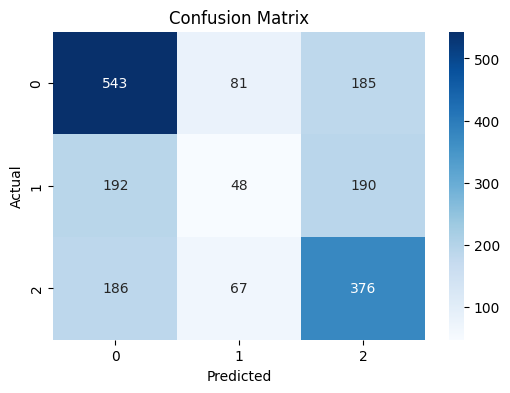

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [40]:
import pandas as pd
from sklearn.metrics import classification_report

report = classification_report(y_test, pred_rf, digits=3, output_dict=True)
report_df = pd.DataFrame(report).transpose()

print(report_df)

              precision    recall  f1-score      support
0              0.589577  0.671199  0.627746   809.000000
1              0.244898  0.111628  0.153355   430.000000
2              0.500666  0.597774  0.544928   629.000000
accuracy       0.517666  0.517666  0.517666     0.517666
macro avg      0.445047  0.460200  0.442009  1868.000000
weighted avg   0.480296  0.517666  0.490657  1868.000000


,precision,recall,f1-score,support
0,0.589577,0.671199,0.627746,809.000000
1,0.244898,0.111628,0.153355,430.000000
2,0.500666,0.597774,0.544928,629.000000
accuracy,0.517666,0.517666,0.517666,0.517666
macro avg,0.445047,0.460200,0.442009,1868.000000
weighted avg,0.480296,0.517666,0.490657,1868.000000


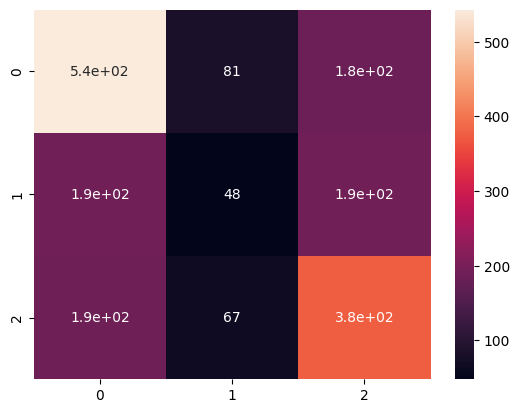

In [42]:
sns.heatmap(confusion_matrix(y_test, pred_rf), annot=True)
pd.DataFrame(classification_report(y_test, pred_rf, output_dict=True)).T

In [24]:
imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(imp.head(25))

AwayElo                           0.051221
TargetShotsRolling20_diff         0.051152
ShotsRolling20_diff               0.050206
HomeElo                           0.049490
ShotsHomeAwayRolling20_diff       0.046345
HomeAwayPointsRolling20_diff      0.044150
TotalPointsRoll20_diff            0.041814
GoalsHomeAwayRolling20_diff       0.038327
HomeTeamShotsHomeRolling20        0.037007
AwayTeamShotsRolling20            0.036891
AwayTeamShotsAwayRolling20        0.036572
GoalsRolling20_diff               0.036282
HomeTeamShotsRolling20            0.034805
ConcededHomeAwayRolling20_diff    0.034598
HomeTeamTargetShotsRolling20      0.033849
AwayTeamTargetShotsRolling20      0.032060
HomeGoalsHomeRolling20            0.029145
HomeConcededHomeRolling20         0.028300
AwayTotalPointsRoll20             0.027882
AwayTeamAwayPointsRolling20       0.027723
AwayConcededAwayRolling20         0.027355
HomeTotalPointsRoll20             0.027102
HomeTeamHomePointsRolling20       0.026914
AwayTotalGo

In [25]:
X_rf_last = X_test.iloc[[-1]]   # double brackets keep it 2D

pred_rf_last = rf.predict(X_rf_last)
proba_rf_last = rf.predict_proba(X_rf_last)

print("Predicted class:", pred_rf_last)
print("Probabilities:", proba_rf_last)

Predicted class: [2]
Probabilities: [[0.24035826 0.28443103 0.4752107 ]]


In [26]:
proba_rf_rng = rf.predict_proba(X_test)

rng = np.random.default_rng(42)

pred_rf_rng = np.array([
    rng.choice(len(p), p=p) for p in proba_rf_rng
])

In [27]:
print("Accuracy:", accuracy_score(y_test, pred_rf_rng))
print("LogLoss:", log_loss(y_test, proba_rf_rng))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred_rf_rng))
print("\nClassification Report:\n", classification_report(y_test, pred_rf_rng, digits=3))

Accuracy: 0.4127408993576017
LogLoss: 0.9937871774525148

Confusion Matrix:
 [[386 210 213]
 [154 119 157]
 [193 170 266]]

Classification Report:
               precision    recall  f1-score   support

           0      0.527     0.477     0.501       809
           1      0.238     0.277     0.256       430
           2      0.418     0.423     0.421       629

    accuracy                          0.413      1868
   macro avg      0.394     0.392     0.392      1868
weighted avg      0.424     0.413     0.417      1868



In [28]:

SEED = 42

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 400, 2500),
        "max_depth": trial.suggest_int("max_depth", 4, 60),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 40),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 25),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced", "balanced_subsample"]),
        "n_jobs": -1,
        "random_state": SEED,
    }

    model_rf = RandomForestClassifier(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    # Optimize for probability quality (lower log loss is better)
    scores = cross_val_score(
        model_rf,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_log_loss",
        n_jobs=-1
    )

    return float(np.mean(scores))  # maximize neg_log_loss

# Study
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED)
)

study.optimize(objective, n_trials=60, show_progress_bar=True)

print("\nBest CV neg_log_loss:", study.best_value)
print("Best params:\n", study.best_params)

# Train final model with best params
rf_opt = RandomForestClassifier(
    **study.best_params,
    n_jobs=-1,
    random_state=SEED
)
rf_opt.fit(X_train, y_train)

[I 2026-03-09 21:01:49,718] A new study created in memory with name: no-name-8615d8be-2bcb-4350-9f84-df4b244f1b5f
Best trial: 0. Best value: -0.998386:   2%|▏         | 1/60 [00:09<09:14,  9.39s/it]

[I 2026-03-09 21:01:59,111] Trial 0 finished with value: -0.9983863616321447 and parameters: {'n_estimators': 1186, 'max_depth': 58, 'min_samples_split': 30, 'min_samples_leaf': 15, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': 'balanced_subsample'}. Best is trial 0 with value: -0.9983863616321447.


Best trial: 1. Best value: -0.995584:   3%|▎         | 2/60 [00:29<15:04, 15.59s/it]

[I 2026-03-09 21:02:19,034] Trial 1 finished with value: -0.9955836378974883 and parameters: {'n_estimators': 2148, 'max_depth': 16, 'min_samples_split': 9, 'min_samples_leaf': 5, 'max_features': 'log2', 'bootstrap': False, 'class_weight': 'balanced_subsample'}. Best is trial 1 with value: -0.9955836378974883.


Best trial: 1. Best value: -0.995584:   5%|▌         | 3/60 [01:03<22:48, 24.01s/it]

...

Best trial: 51. Best value: -0.974003:  98%|█████████▊| 59/60 [12:49<00:04,  4.80s/it]

[I 2026-03-09 21:14:38,724] Trial 58 finished with value: -1.0065140067070233 and parameters: {'n_estimators': 1148, 'max_depth': 6, 'min_samples_split': 40, 'min_samples_leaf': 21, 'max_features': 'sqrt', 'bootstrap': False, 'class_weight': 'balanced'}. Best is trial 51 with value: -0.9740034733555951.


Best trial: 51. Best value: -0.974003: 100%|██████████| 60/60 [12:53<00:00, 12.89s/it]


[I 2026-03-09 21:14:43,077] Trial 59 finished with value: -0.9747636341414602 and parameters: {'n_estimators': 953, 'max_depth': 19, 'min_samples_split': 38, 'min_samples_leaf': 24, 'max_features': 'log2', 'bootstrap': True, 'class_weight': None}. Best is trial 51 with value: -0.9740034733555951.

Best CV neg_log_loss: -0.9740034733555951
Best params:
 {'n_estimators': 951, 'max_depth': 6, 'min_samples_split': 39, 'min_samples_leaf': 20, 'max_features': 'log2', 'bootstrap': True, 'class_weight': None}


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",951
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",39
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [29]:
# Evaluate on test set
pred_rf_opt = rf_opt.predict(X_test)
proba_rf_opt = rf_opt.predict_proba(X_test)

print("\nTEST Accuracy:", accuracy_score(y_test, pred_rf_opt))
print("TEST LogLoss:", log_loss(y_test, proba_rf_opt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred_rf_opt))
print("\nClassification Report:\n", classification_report(y_test, pred_rf_opt, digits=3))


TEST Accuracy: 0.538543897216274
TEST LogLoss: 0.9787084305920037

Confusion Matrix:
 [[677   0 132]
 [281   0 149]
 [300   0 329]]

Classification Report:
               precision    recall  f1-score   support

           0      0.538     0.837     0.655       809
           1      0.000     0.000     0.000       430
           2      0.539     0.523     0.531       629

    accuracy                          0.539      1868
   macro avg      0.359     0.453     0.395      1868
weighted avg      0.415     0.539     0.463      1868



c:\Users\mikko\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mikko\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mikko\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [30]:
proba_opt_rng = rf_opt.predict_proba(X_test)

rng = np.random.default_rng(42)

pred_opt_rng = np.array([
    rng.choice(len(p), p=p) for p in proba_opt_rng
])

In [31]:
print("TEST Accuracy:", accuracy_score(y_test, pred_opt_rng))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred_rf))
print("\nClassification Report:\n", classification_report(y_test, pred_opt_rng, digits=3))

TEST Accuracy: 0.42451820128479656

Confusion Matrix:
 [[543  81 185]
 [192  48 190]
 [186  67 376]]

Classification Report:
               precision    recall  f1-score   support

           0      0.516     0.544     0.530       809
           1      0.238     0.235     0.236       430
           2      0.426     0.401     0.413       629

    accuracy                          0.425      1868
   macro avg      0.393     0.393     0.393      1868
weighted avg      0.422     0.425     0.423      1868



In [32]:
X_rf_last = X_test.iloc[[-1]]   # double brackets keep it 2D

pred_rf_last = rf_opt.predict(X_rf_last)
proba_rf_last = rf_opt.predict_proba(X_rf_last)

print("Predicted class:", pred_rf_last)
print("Probabilities:", proba_rf_last)

Predicted class: [2]
Probabilities: [[0.31299716 0.27814829 0.40885454]]


In [33]:
model_xb = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=5000,
    learning_rate=0.1,      
    max_depth=4,            
    min_child_weight=5,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    tree_method="hist",
    eval_metric="mlogloss",
    early_stopping_rounds=200,  
    random_state=42,
)

model_xb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)

#metrics
proba_xb = model_xb.predict_proba(X_test)
pred_xb = proba_xb.argmax(axis=1)

print("Accuracy:", accuracy_score(y_test, pred_xb))
print("LogLoss:", log_loss(y_test, proba_xb))

print(confusion_matrix(y_test, pred_xb))
print(classification_report(y_test, pred_xb, digits=3))

[0]	validation_0-mlogloss:1.06005
[100]	validation_0-mlogloss:0.99728
[200]	validation_0-mlogloss:1.01779
[230]	validation_0-mlogloss:1.02362
Accuracy: 0.528372591006424
LogLoss: 0.9857930185095406
[[677   3 129]
 [281   1 148]
 [314   6 309]]
              precision    recall  f1-score   support

           0      0.532     0.837     0.651       809
           1      0.100     0.002     0.005       430
           2      0.527     0.491     0.509       629

    accuracy                          0.528      1868
   macro avg      0.387     0.443     0.388      1868
weighted avg      0.431     0.528     0.454      1868



In [34]:
X_xb_w_last = X_test.iloc[[-1]]   # double brackets keep it 2D

pred_xb_last = model_xb.predict(X_xb_w_last)
proba_xb_last = model_xb.predict_proba(X_xb_w_last)

print("Predicted class:", pred_xb_last)
print("Probabilities:", proba_xb_last)

Predicted class: [2]
Probabilities: [[0.3042779  0.23125075 0.4644713 ]]


In [35]:


SEED = 42
N_CLASSES = 3

# convert y if DataFrame with one column
if hasattr(y_train, "shape") and len(y_train.shape) == 2:
    y_train = y_train.iloc[:,0]
    y_test = y_test.iloc[:,0]

def objective(trial):

    params_xgbo = {
        "objective": "multi:softprob",
        "num_class": N_CLASSES,
        "tree_method": "hist",
        "eval_metric": "mlogloss",
        "random_state": SEED,
        "n_jobs": -1,

        # hyperparameters to tune
        "n_estimators": trial.suggest_int("n_estimators", 1000, 12000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 20.0),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 50.0, log=True),

        "gamma": trial.suggest_float("gamma", 0.0, 10.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 5.0, log=True),

        # early stopping goes HERE for xgboost >=3
        "early_stopping_rounds": 200,
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    losses = []

    for tr_idx, va_idx in cv.split(X_train, y_train):

        X_tr = X_train.iloc[tr_idx]
        X_va = X_train.iloc[va_idx]
        y_tr = y_train.iloc[tr_idx]
        y_va = y_train.iloc[va_idx]

        model_xgb_o = xgb.XGBClassifier(**params_xgbo)

        model_xgb_o.fit(
            X_tr,
            y_tr,
            eval_set=[(X_va, y_va)],
            verbose=False
        )

        proba_xgbo = model_xgb_o.predict_proba(X_va)
        losses.append(log_loss(y_va, proba_xgbo, labels=np.arange(N_CLASSES)))

    return -np.mean(losses)


study_xgb = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED)
)

study_xgb.optimize(objective, n_trials=60, show_progress_bar=True)

print("\nBest CV neg_log_loss:", study_xgb.best_value)
print("Best params:\n", study_xgb.best_params)


# ---- train final optimized model ----

best_params_xgb = {
    **study_xgb.best_params,
    "objective": "multi:softprob",
    "num_class": N_CLASSES,
    "tree_method": "hist",
    "eval_metric": "mlogloss",
    "random_state": SEED,
    "n_jobs": -1,
    "early_stopping_rounds": 200,
}

model_xb_opt = xgb.XGBClassifier(**best_params_xgb)

model_xb_opt.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)


[I 2026-03-09 21:14:47,834] A new study created in memory with name: no-name-b61601ba-99aa-4ea0-8a73-132127080ac1
Best trial: 0. Best value: -0.976339:   2%|▏         | 1/60 [00:04<04:54,  4.99s/it]

[I 2026-03-09 21:14:52,819] Trial 0 finished with value: -0.9763387531703787 and parameters: {'n_estimators': 5120, 'learning_rate': 0.2536999076681772, 'max_depth': 8, 'min_child_weight': 12.374511199743695, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'reg_lambda': 0.0018747059221802516, 'gamma': 8.661761457749352, 'reg_alpha': 0.0016946556203947059}. Best is trial 0 with value: -0.9763387531703787.


Best trial: 1. Best value: -0.97428:   3%|▎         | 2/60 [00:13<06:52,  7.12s/it] 

[I 2026-03-09 21:15:01,428] Trial 1 finished with value: -0.9742797887563178 and parameters: {'n_estimators': 8789, 'learning_rate': 0.010725209743171996, 'max_depth': 10, 'min_child_weight': 16.816410175208013, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.5909124836035503, 'reg_lambda': 0.0072746531356694235, 'gamma': 3.0424224295953772, 'reg_alpha': 0.0003671474011048667}. Best is trial 1 with value: -0.9742797887563178.


Best trial: 1. Best value: -0.97428:   5%|▌         | 3/60 [00:24<08:24,  8.85s/it]

...

[I 2026-03-09 21:21:19,446] Trial 58 finished with value: -0.9741757650094727 and parameters: {'n_estimators': 7727, 'learning_rate': 0.057245502785704006, 'max_depth': 8, 'min_child_weight': 10.992491979986042, 'subsample': 0.6882232331299647, 'colsample_bytree': 0.6628337668338861, 'reg_lambda': 0.005174320312247845, 'gamma': 3.7479576797913885, 'reg_alpha': 6.747491278803308e-06}. Best is trial 41 with value: -0.9732155657230992.


Best trial: 59. Best value: -0.973063: 100%|██████████| 60/60 [06:38<00:00,  6.64s/it]

[I 2026-03-09 21:21:26,419] Trial 59 finished with value: -0.9730629466290394 and parameters: {'n_estimators': 4332, 'learning_rate': 0.01789269576971008, 'max_depth': 10, 'min_child_weight': 4.825799127549914, 'subsample': 0.5300916575240049, 'colsample_bytree': 0.5883615110150762, 'reg_lambda': 0.02516502304244902, 'gamma': 4.614151718031739, 'reg_alpha': 2.5605700319869678e-06}. Best is trial 59 with value: -0.9730629466290394.

Best CV neg_log_loss: -0.9730629466290394
Best params:
 {'n_estimators': 4332, 'learning_rate': 0.01789269576971008, 'max_depth': 10, 'min_child_weight': 4.825799127549914, 'subsample': 0.5300916575240049, 'colsample_bytree': 0.5883615110150762, 'reg_lambda': 0.02516502304244902, 'gamma': 4.614151718031739, 'reg_alpha': 2.5605700319869678e-06}
[0]	validation_0-mlogloss:1.07076


[100]	validation_0-mlogloss:0.98523
[200]	validation_0-mlogloss:0.97929
[300]	validation_0-mlogloss:0.97921
[400]	validation_0-mlogloss:0.97936
[441]	validation_0-mlogloss:0.97930


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.5883615110150762
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",200
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

In [36]:
# metrics
proba_xb_o = model_xb_opt.predict_proba(X_test)
pred_xb_o = proba_xb_o.argmax(axis=1)

print("\nAccuracy:", accuracy_score(y_test, pred_xb_o))
print("LogLoss:", log_loss(y_test, proba_xb_o))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred_xb_o))
print("\nClassification Report:\n", classification_report(y_test, pred_xb_o, digits=3))


Accuracy: 0.5310492505353319
LogLoss: 0.9789725151040787

Confusion Matrix:
 [[663   0 146]
 [283   0 147]
 [300   0 329]]

Classification Report:
               precision    recall  f1-score   support

           0      0.532     0.820     0.645       809
           1      0.000     0.000     0.000       430
           2      0.529     0.523     0.526       629

    accuracy                          0.531      1868
   macro avg      0.354     0.448     0.390      1868
weighted avg      0.409     0.531     0.457      1868



c:\Users\mikko\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mikko\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mikko\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [37]:
proba_xgbo_opt_rng = model_xb_opt.predict_proba(X_test)

rng_xgbo = np.random.default_rng(42)

pred_xgbo_opt_rng = np.array([
    rng.choice(len(p), p=p) for p in proba_xgbo_opt_rng
])

In [38]:
print("TEST Accuracy:", accuracy_score(y_test, pred_xgbo_opt_rng))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred_xgbo_opt_rng))
print("\nClassification Report:\n", classification_report(y_test, pred_xgbo_opt_rng, digits=3))

TEST Accuracy: 0.45610278372591007

Confusion Matrix:
 [[459 168 182]
 [185 123 122]
 [226 133 270]]

Classification Report:
               precision    recall  f1-score   support

           0      0.528     0.567     0.547       809
           1      0.290     0.286     0.288       430
           2      0.470     0.429     0.449       629

    accuracy                          0.456      1868
   macro avg      0.429     0.428     0.428      1868
weighted avg      0.454     0.456     0.454      1868



In [39]:
X_xb_o_last = X_test.iloc[[-1]]   # double brackets keep it 2D

pred_xb_o_last = model_xb_opt.predict(X_xb_o_last)
proba_xb_o_last = model_xb_opt.predict_proba(X_xb_o_last)

print("Predicted class:", pred_xb_o_last)
print("Probabilities:", proba_xb_o_last)

Predicted class: [2]
Probabilities: [[0.304218   0.25660953 0.43917248]]
